# 1D Speckle Generation & Analysis

**Scott Prahl**

A speckle pattern is the irradiance produced when coherent light scatters from
a rough surface: many randomly phased wavelets interfere, and the result is a
grainy pattern of bright and dark regions.

This notebook covers

1. **fully developed speckle**, polarized and unpolarized, and
2. **partially developed speckle**, where the surface is too smooth to
   randomize the phase completely.

Speckle irradiance is *exponentially* distributed and never negative.  That is
quite different from the correlated Gaussian sequences in the *Correlated
Random Sequences* notebook, which are sometimes mistaken for speckle because
one of them is also named "exponential".  There the word describes the
autocorrelation; here it describes the distribution of irradiance.

In [1]:
%config InlineBackend.figure_format = 'retina'

import sys
import numpy as np
import matplotlib.pyplot as plt

if sys.platform == "emscripten":
    import piplite

    await piplite.install("pyspeckle")

import pyspeckle

# fix the seed so re-running this notebook reproduces the same figures
np.random.seed(0)

## Fully developed speckle

When the surface roughness is much larger than the wavelength, the scattered
phase is uniformly distributed over $2\pi$ and the speckle is *fully
developed*.  `create_exponential(M, pix_per_speckle)` builds this directly:
uniform random phase across an aperture, Fourier transformed, magnitude
squared.

`pix_per_speckle` sets the sampling.  A value of 2 is the Nyquist limit, 8
gives eight pixels across the smallest speckle.

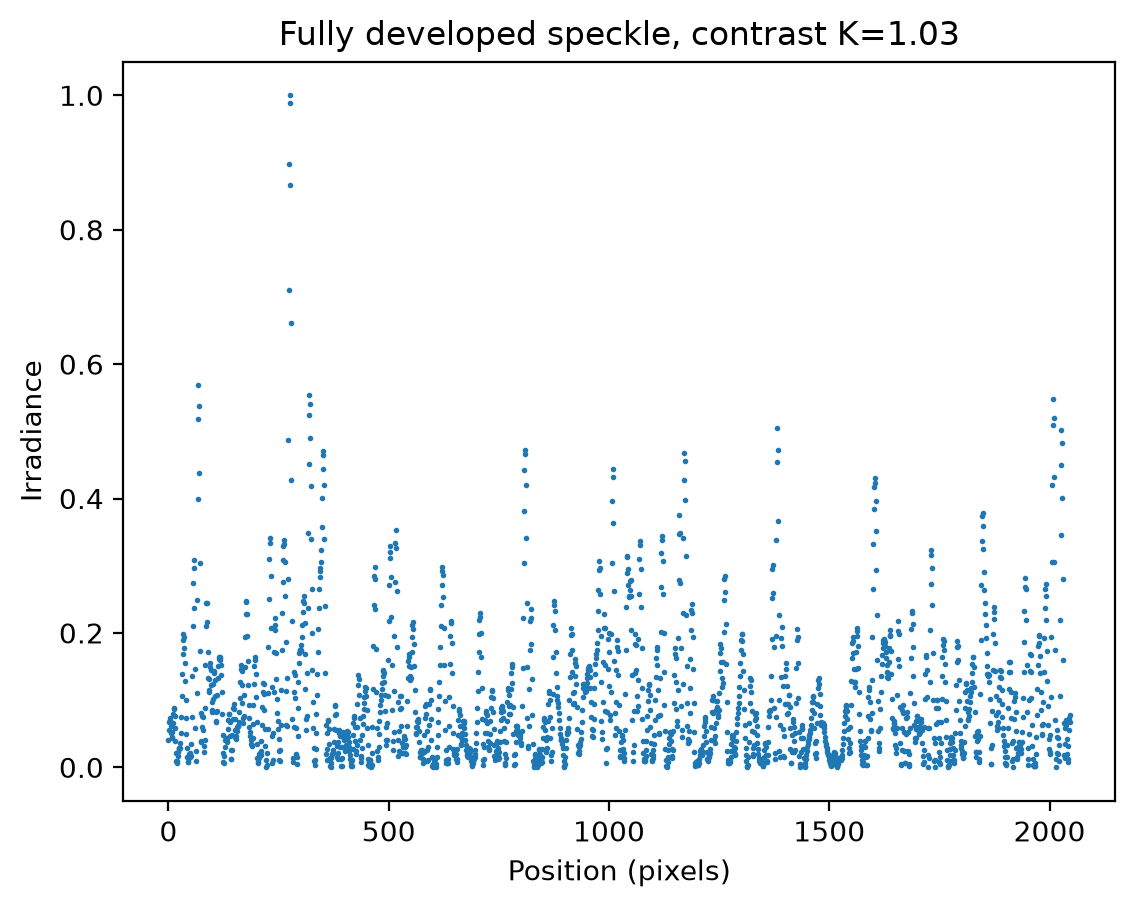

In [2]:
M = 2048
speckle = pyspeckle.create_exponential(M, 8)

plt.plot(speckle, ".", markersize=2)
plt.xlabel("Position (pixels)")
plt.ylabel("Irradiance")
plt.title("Fully developed speckle, contrast K=%.2f" % (np.std(speckle) / np.mean(speckle)))
plt.show()

### The irradiance is exponentially distributed

For fully developed polarized speckle the probability density of the
irradiance is

$$
p(I) = \frac{1}{\langle I\rangle}\exp\left(-\frac{I}{\langle I\rangle}\right)
$$

so the most likely value is *zero* -- dark points are the most common.  The
speckle contrast, the ratio of standard deviation to mean, is exactly one.

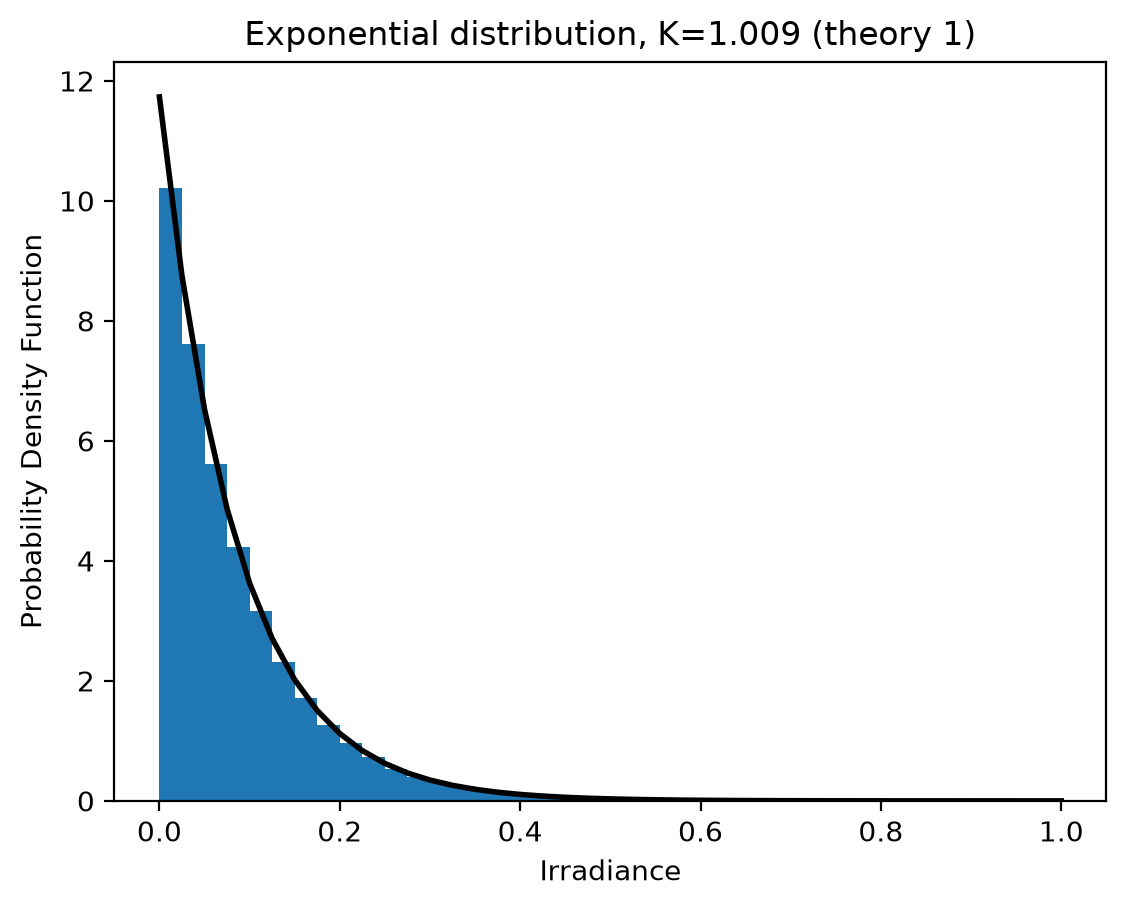

In [3]:
speckle = pyspeckle.create_exponential(100000, 4)
mean = np.mean(speckle)

count, bins, ignored = plt.hist(speckle, 40, density=True)
plt.plot(bins, np.exp(-bins / mean) / mean, "k", lw=2)
plt.xlabel("Irradiance")
plt.ylabel("Probability Density Function")
plt.title("Exponential distribution, K=%.3f (theory 1)" % (np.std(speckle) / mean))
plt.show()

### Speckle size

The speckle size is set by the aperture, and `pix_per_speckle` controls how
finely it is sampled.  The autocorrelation width grows in proportion.

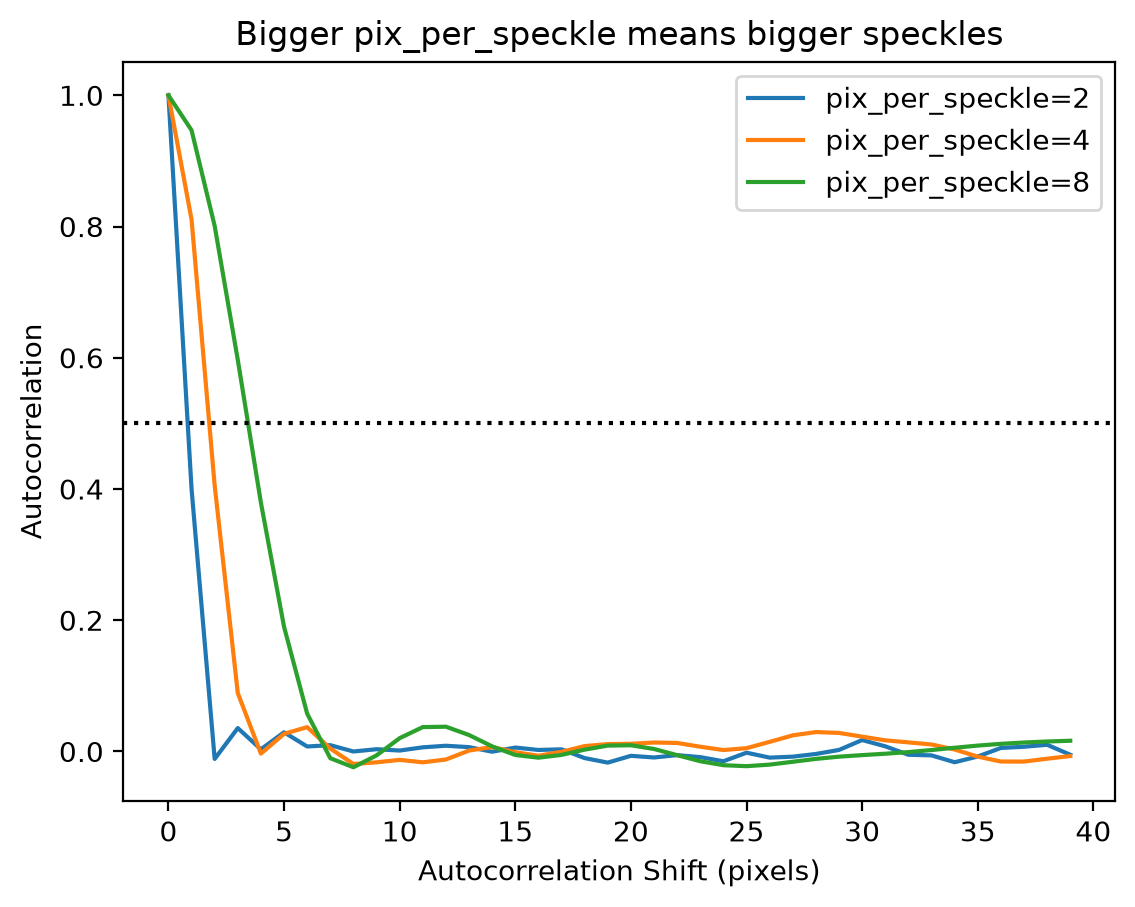

In [4]:
for pix_per_speckle in [2, 4, 8]:
    speckle = pyspeckle.create_exponential(16384, pix_per_speckle)
    ac = pyspeckle.autocorrelation(speckle)
    plt.plot(ac[:40], label="pix_per_speckle=%d" % pix_per_speckle)

plt.axhline(0.5, color="black", ls=":")
plt.xlabel("Autocorrelation Shift (pixels)")
plt.ylabel("Autocorrelation")
plt.title("Bigger pix_per_speckle means bigger speckles")
plt.legend()
plt.show()

### All the statistics at once

`statistics_plot_1D` collects the useful views into one figure: the trace, the
probability density of the irradiance, the power spectral density, and that
same density on a log scale, where a fully developed pattern is a straight
line.

The power spectral density is the frequency-domain counterpart of the
autocorrelation above.  It cuts off at $1/\mathtt{pix\_per\_speckle}$, so at 8
pixels per speckle the energy is confined within $\pm0.125$ cycles per pixel.
Sampling at Nyquist would push that cutoff out to the edge of the plot.

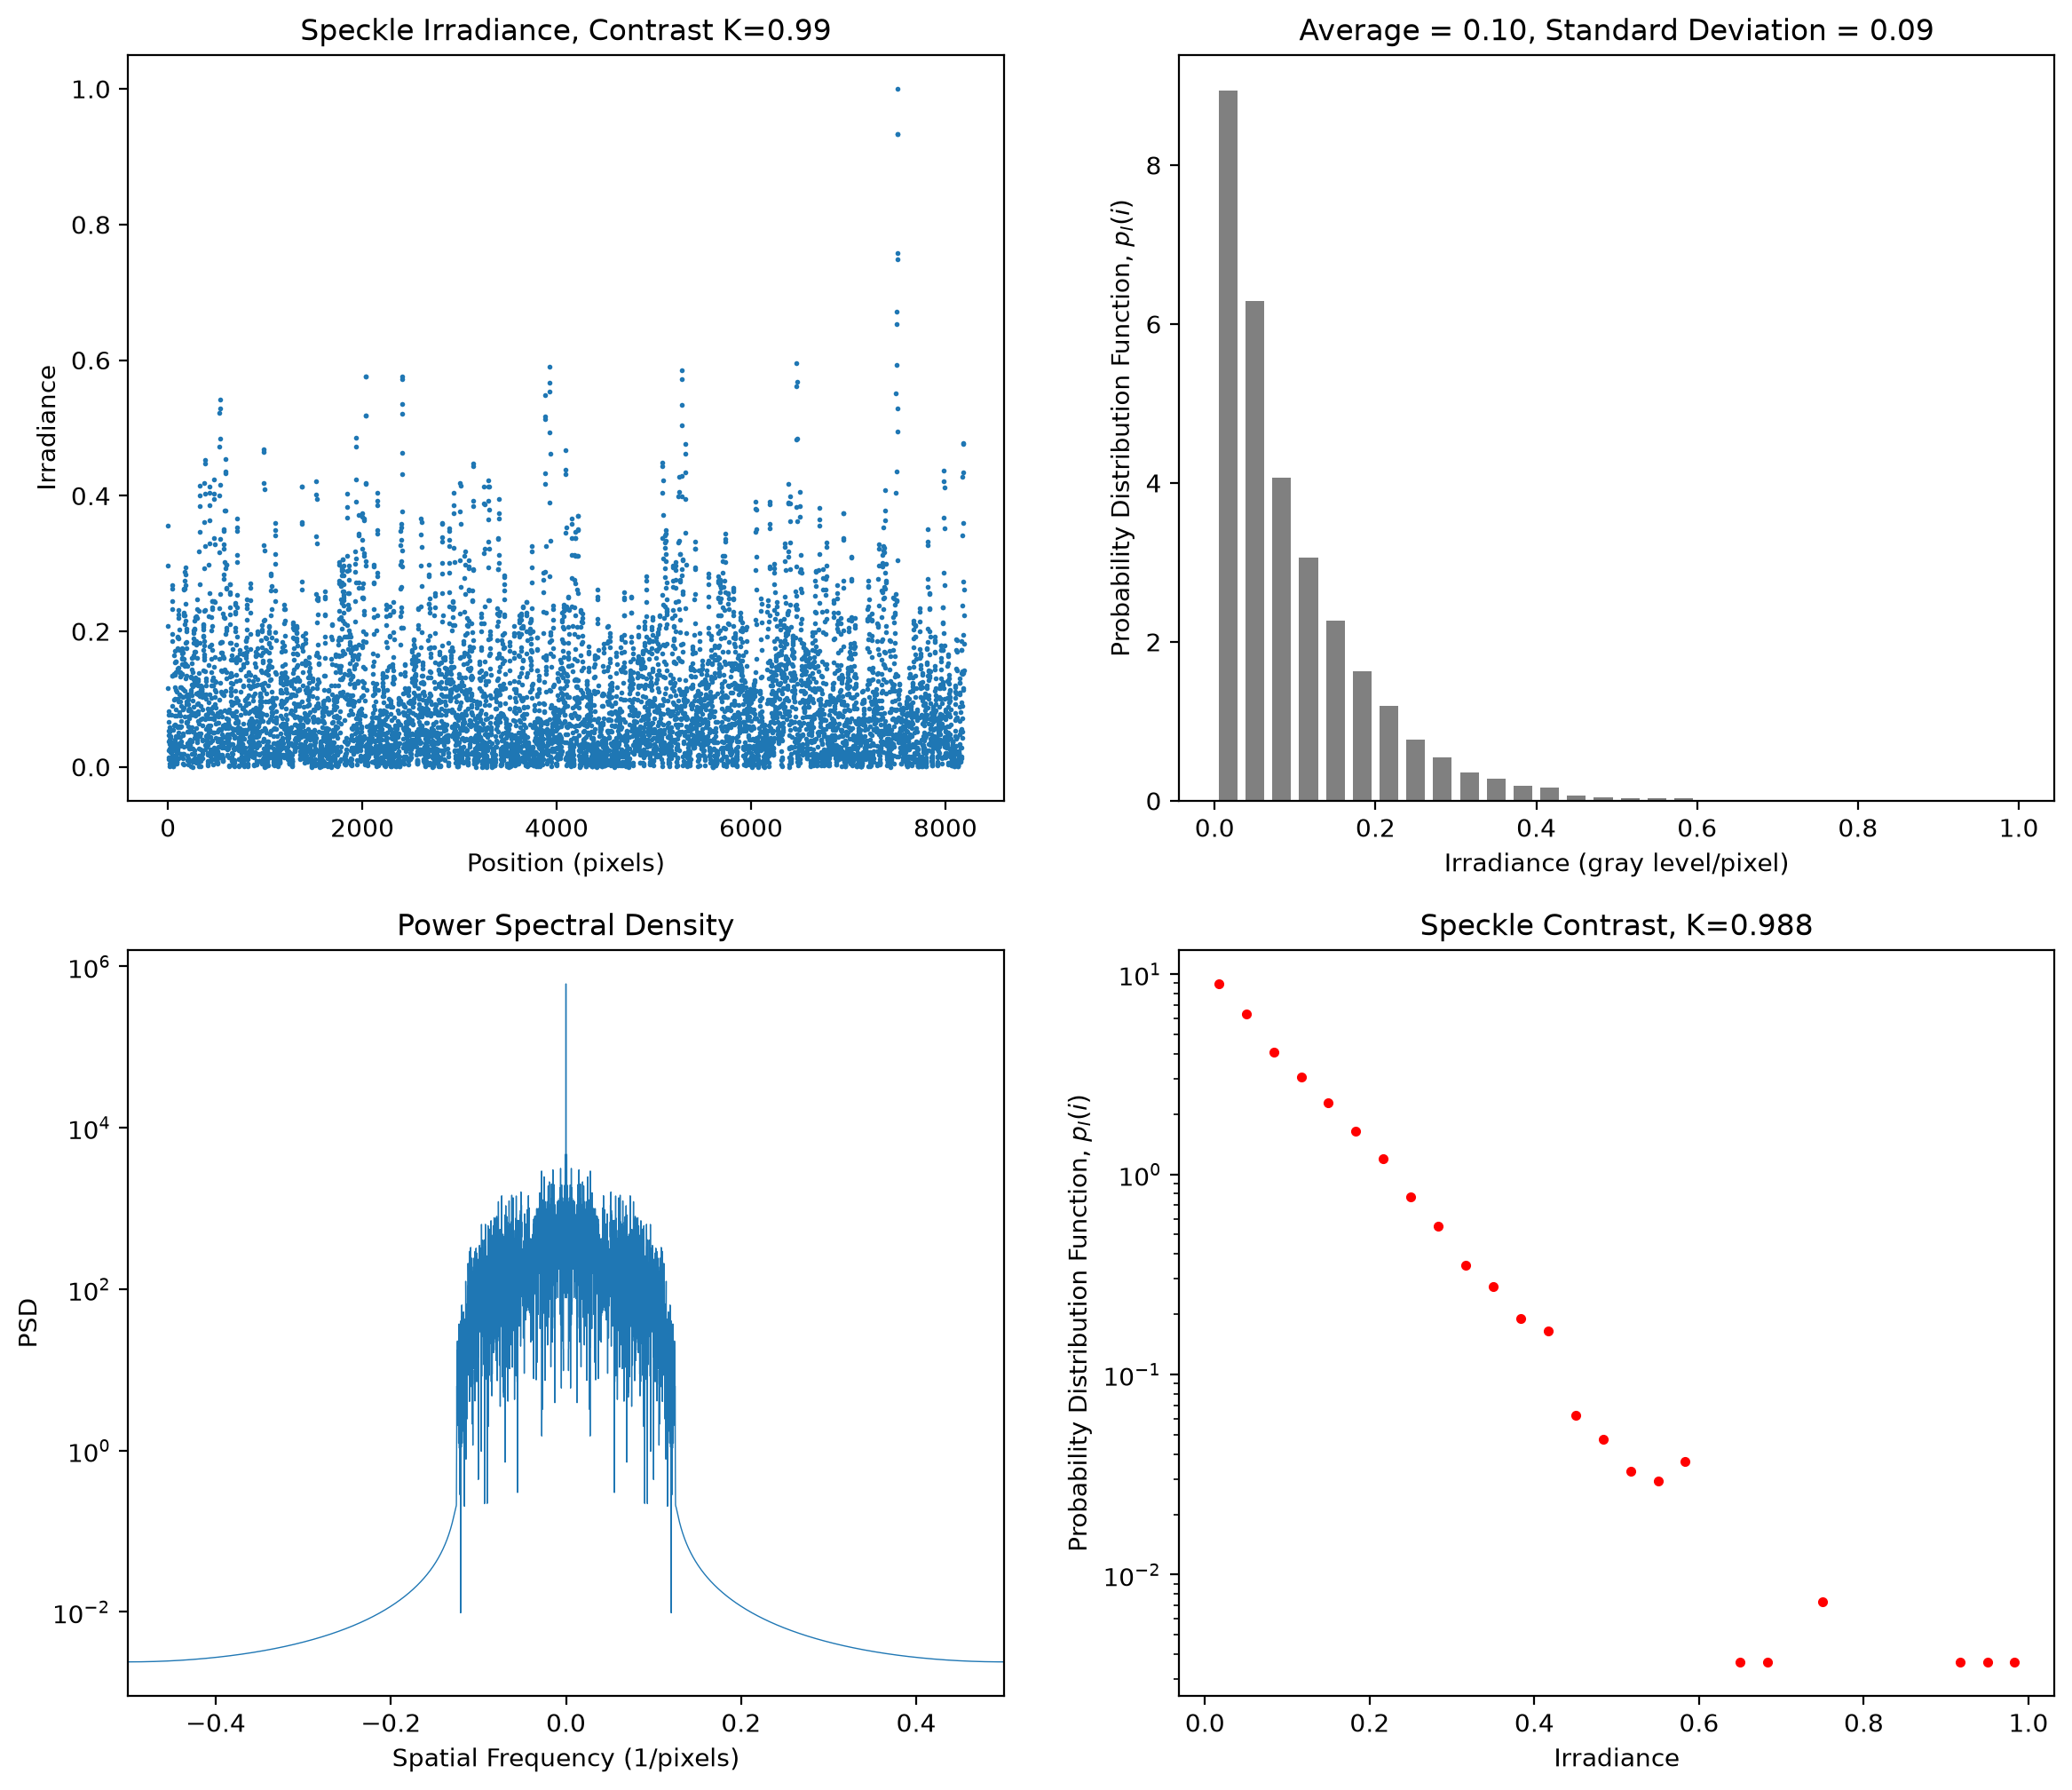

In [5]:
speckle = pyspeckle.create_exponential(8192, 8)
pyspeckle.statistics_plot_1D(speckle)
plt.show()

### Polarized and unpolarized speckle

Unpolarized light is the incoherent sum of two independent speckle patterns,
one per polarization state.  Adding two exponentials gives a gamma
distribution with shape 2, and the contrast drops from 1 to $1/\sqrt{2}$.

`create_unpolarized` is exactly `create_exponential(..., polarization=0)`.

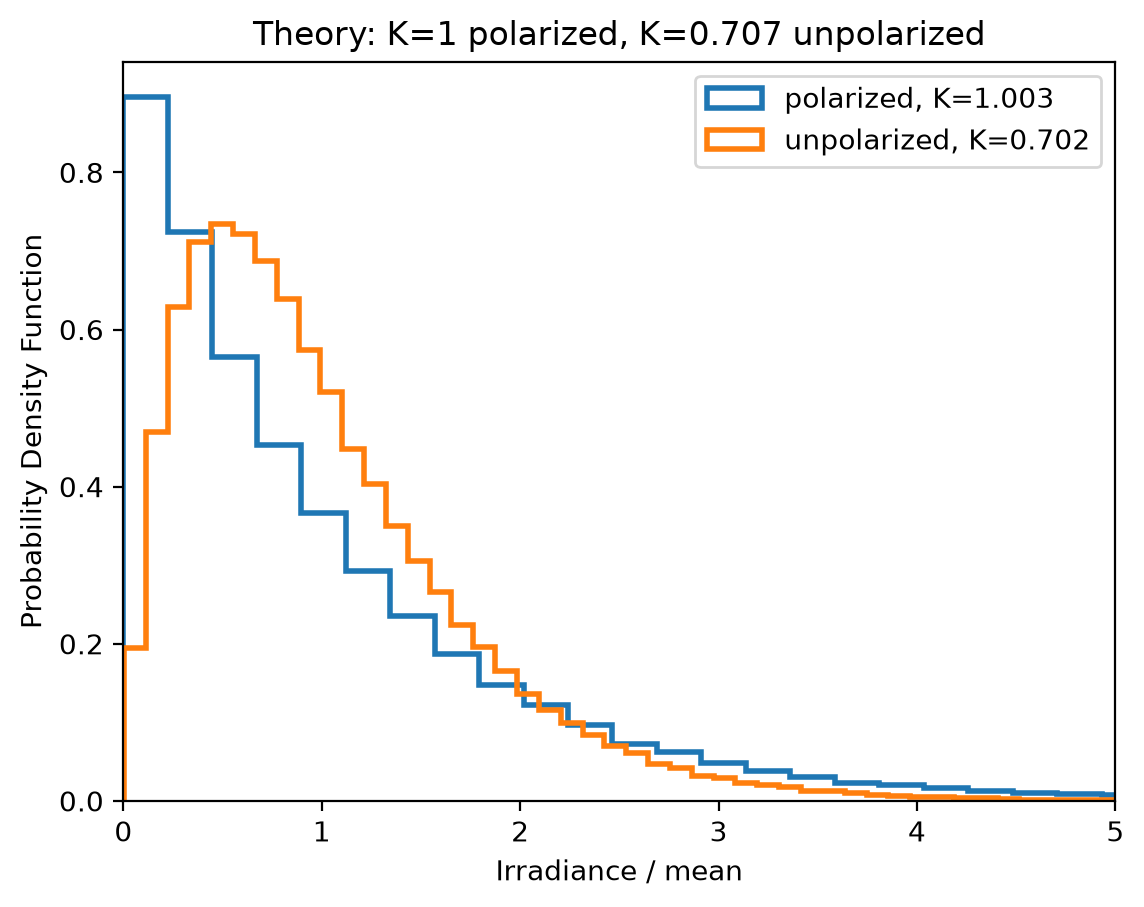

In [6]:
M = 100000
polarized = pyspeckle.create_exponential(M, 4)
unpolarized = pyspeckle.create_unpolarized(M, 4)

for data, label in [(polarized, "polarized"), (unpolarized, "unpolarized")]:
    K = np.std(data) / np.mean(data)
    plt.hist(data / np.mean(data), 60, density=True, histtype="step", lw=2, label="%s, K=%.3f" % (label, K))

plt.xlabel("Irradiance / mean")
plt.ylabel("Probability Density Function")
plt.title("Theory: K=1 polarized, K=%.3f unpolarized" % (1 / np.sqrt(2)))
plt.xlim(0, 5)
plt.legend()
plt.show()

## Local contrast

Speckle contrast is the standard deviation divided by the mean.  Measured over
a whole pattern it is a single number, but it is often more useful measured
over a sliding window, because the window follows variation along the trace.

`local_contrast(x, kernel)` returns both: the contrast at every window
position and the contrast of the whole trace.  Only valid window positions are
returned, so for an `M`-long trace and an `N`-long kernel there are `M-N+1`
values and none of them are contaminated by the ends.

### The window has to hold enough speckles

A window covering only a few speckles gives a noisy estimate, and one that is
biased low: the contrast of a handful of samples systematically underestimates
the true value.  The estimate creeps up toward the global contrast of 1 as the
window grows.

This is the single most common way to get local speckle contrast wrong, so it
is worth seeing the size of the effect.

global contrast K = 0.994

  window   speckles   mean C   spread
       5        2.5    0.691    0.222
      11        5.5    0.824    0.199
      25       12.5    0.910    0.168
      51       25.5    0.952    0.136
     101       50.5    0.972    0.105
     201      100.5    0.982    0.077
     401      200.5    0.989    0.058


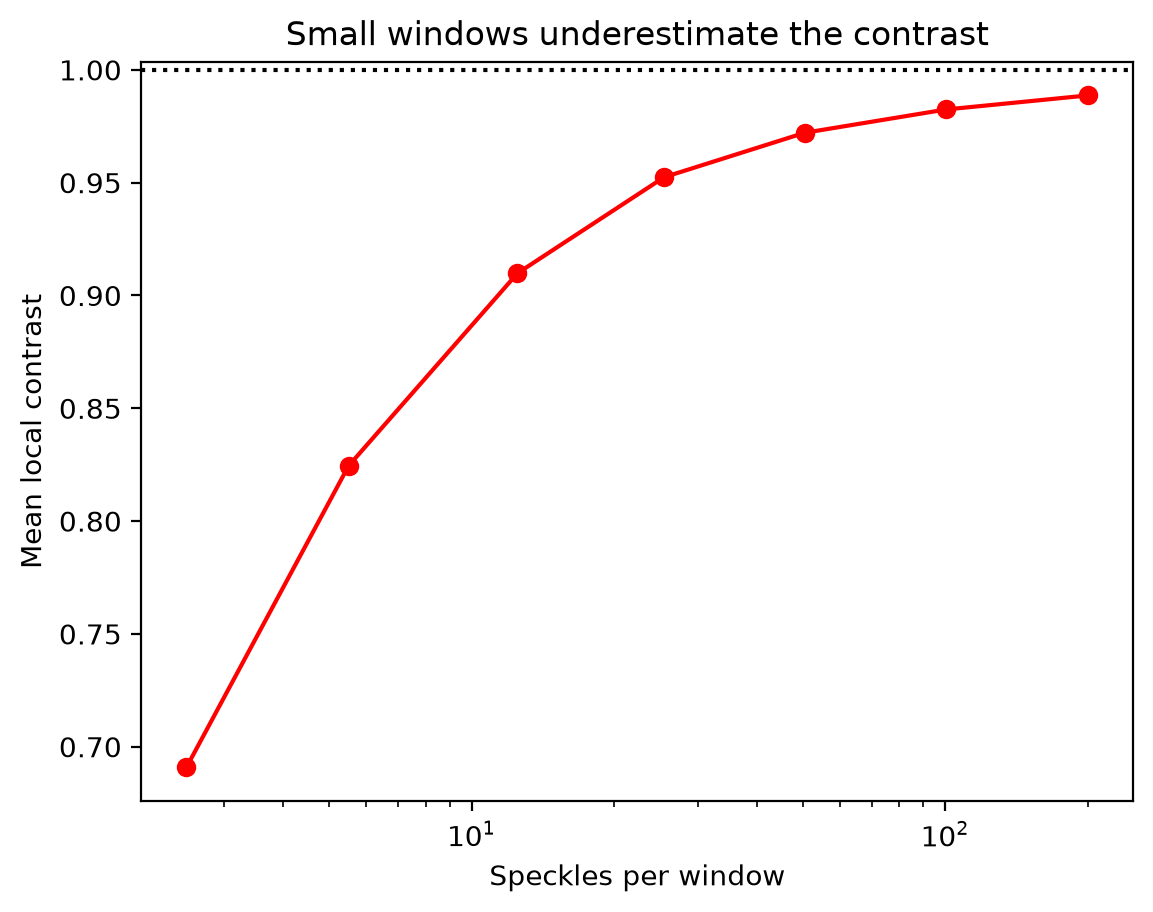

In [7]:
speckle = pyspeckle.create_exponential(16384, 2)
print("global contrast K = %.3f" % (np.std(speckle) / np.mean(speckle)))
print()
print("  window   speckles   mean C   spread")
windows = [5, 11, 25, 51, 101, 201, 401]
means = []
for n in windows:
    C, K = pyspeckle.local_contrast(speckle, np.ones(n))
    means.append(np.mean(C))
    print("  %6d   %8.1f   %6.3f   %6.3f" % (n, n / 2, np.mean(C), np.std(C)))

plt.semilogx(np.array(windows) / 2, means, "ro-")
plt.axhline(1.0, color="black", ls=":")
plt.xlabel("Speckles per window")
plt.ylabel("Mean local contrast")
plt.title("Small windows underestimate the contrast")
plt.show()

### Putting it together

`local_contrast_1D_plot` draws the trace, the local contrast, and the
distribution of each.  The contrast trace is plotted against the centre of its
window so the two left panels share a position axis.

Here the window is 201 pixels at 2 pixels per speckle, about 100 speckles, so
from the table above the local contrast should sit near 0.99.

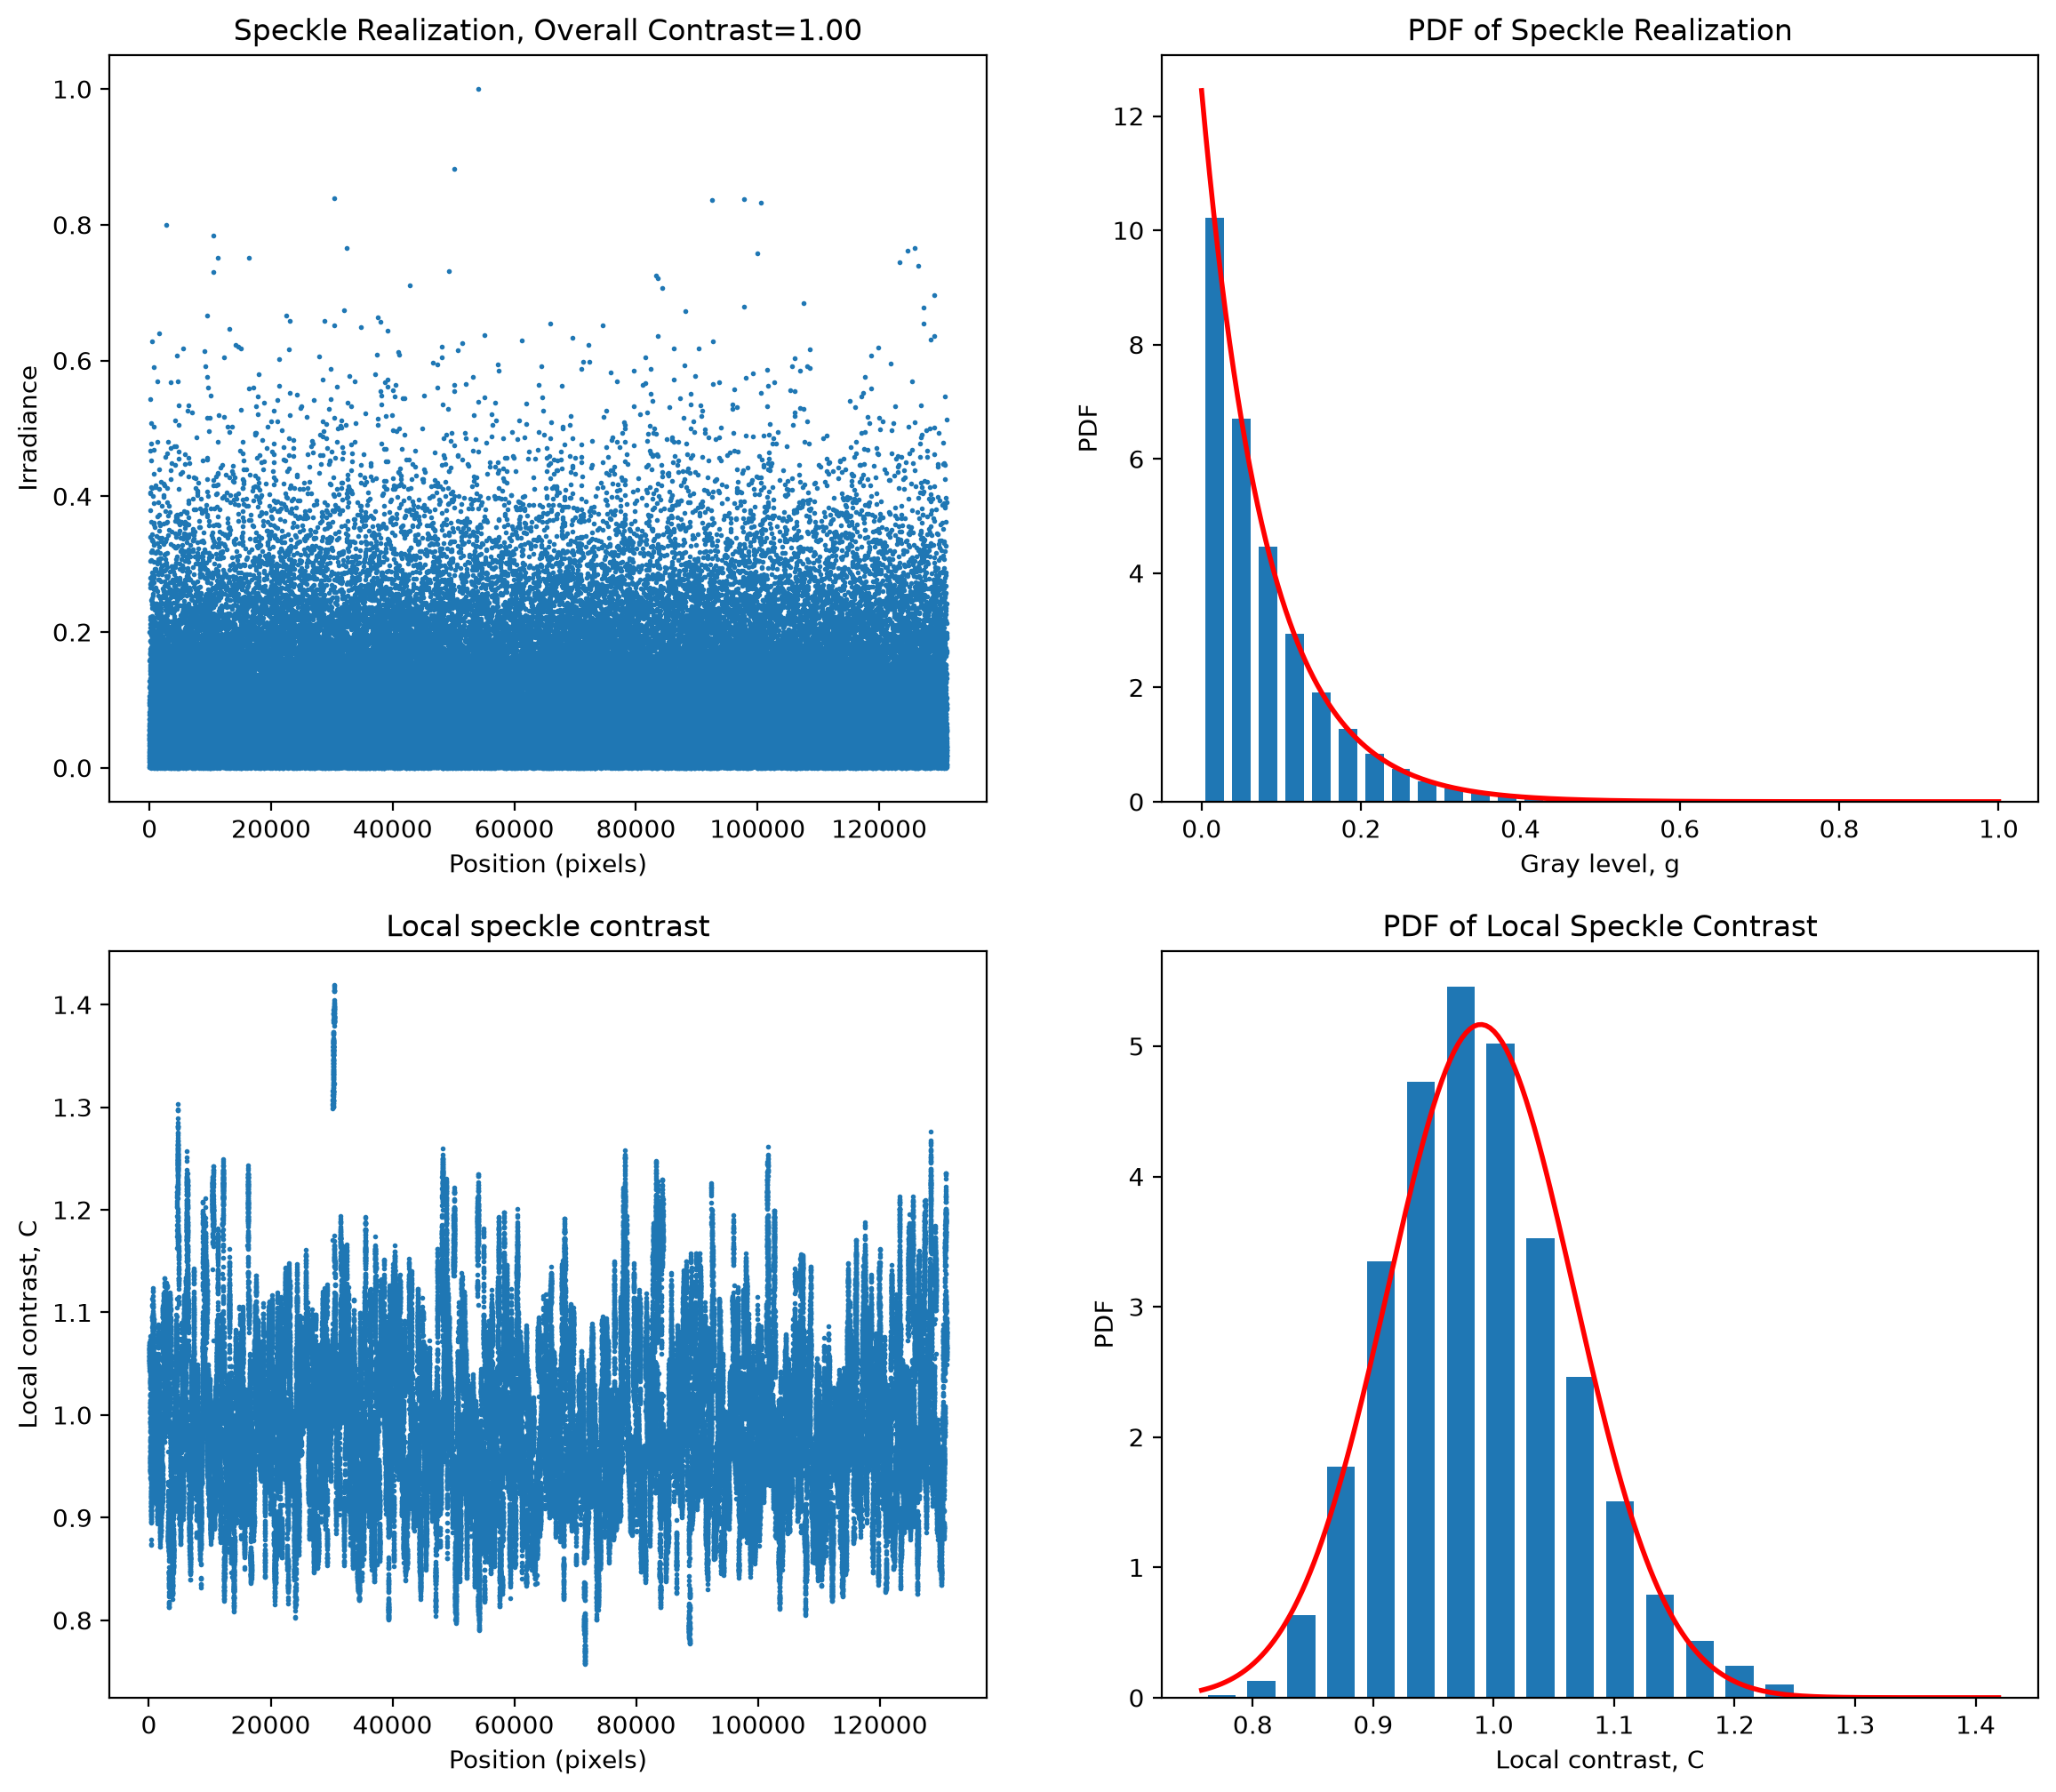

In [8]:
M, pix_per_speckle, n = 131072, 2, 201

speckle = pyspeckle.create_exponential(M, pix_per_speckle)
kernel = np.ones(n)
pyspeckle.local_contrast_1D_plot(speckle, kernel)

# theoretical exponential PDF over the speckle histogram
plt.subplot(222)
g = np.linspace(0, speckle.max(), 200)
plt.plot(g, np.exp(-g / speckle.mean()) / speckle.mean(), "r", lw=2)

# gaussian fit over the local-contrast histogram
plt.subplot(224)
C, _ = pyspeckle.local_contrast(speckle, kernel)
c = np.linspace(C.min(), C.max(), 200)
plt.plot(c, np.exp(-((c - C.mean()) ** 2) / (2 * C.std() ** 2)) / (C.std() * np.sqrt(2 * np.pi)), "r", lw=2)

plt.show()

## Phase screens

A phase screen is the phase a rough surface imposes on the light it reflects.
`create_phase_screen(M, sigma, cl, shape)` generates one: a zero-mean
Gaussian random process measured in **radians**, with standard deviation
`sigma` and correlation length `cl` pixels.

It is worth being clear about what the arguments do, because the screen is an
*input* to a scattering calculation rather than a speckle pattern:

* `sigma` -- how far the phase wanders, in radians.  This sets how much light
  is scattered.
* `cl` -- how quickly the phase varies along the surface, in pixels.
* `shape` -- `'gaussian'` or `'exponential'` autocorrelation.

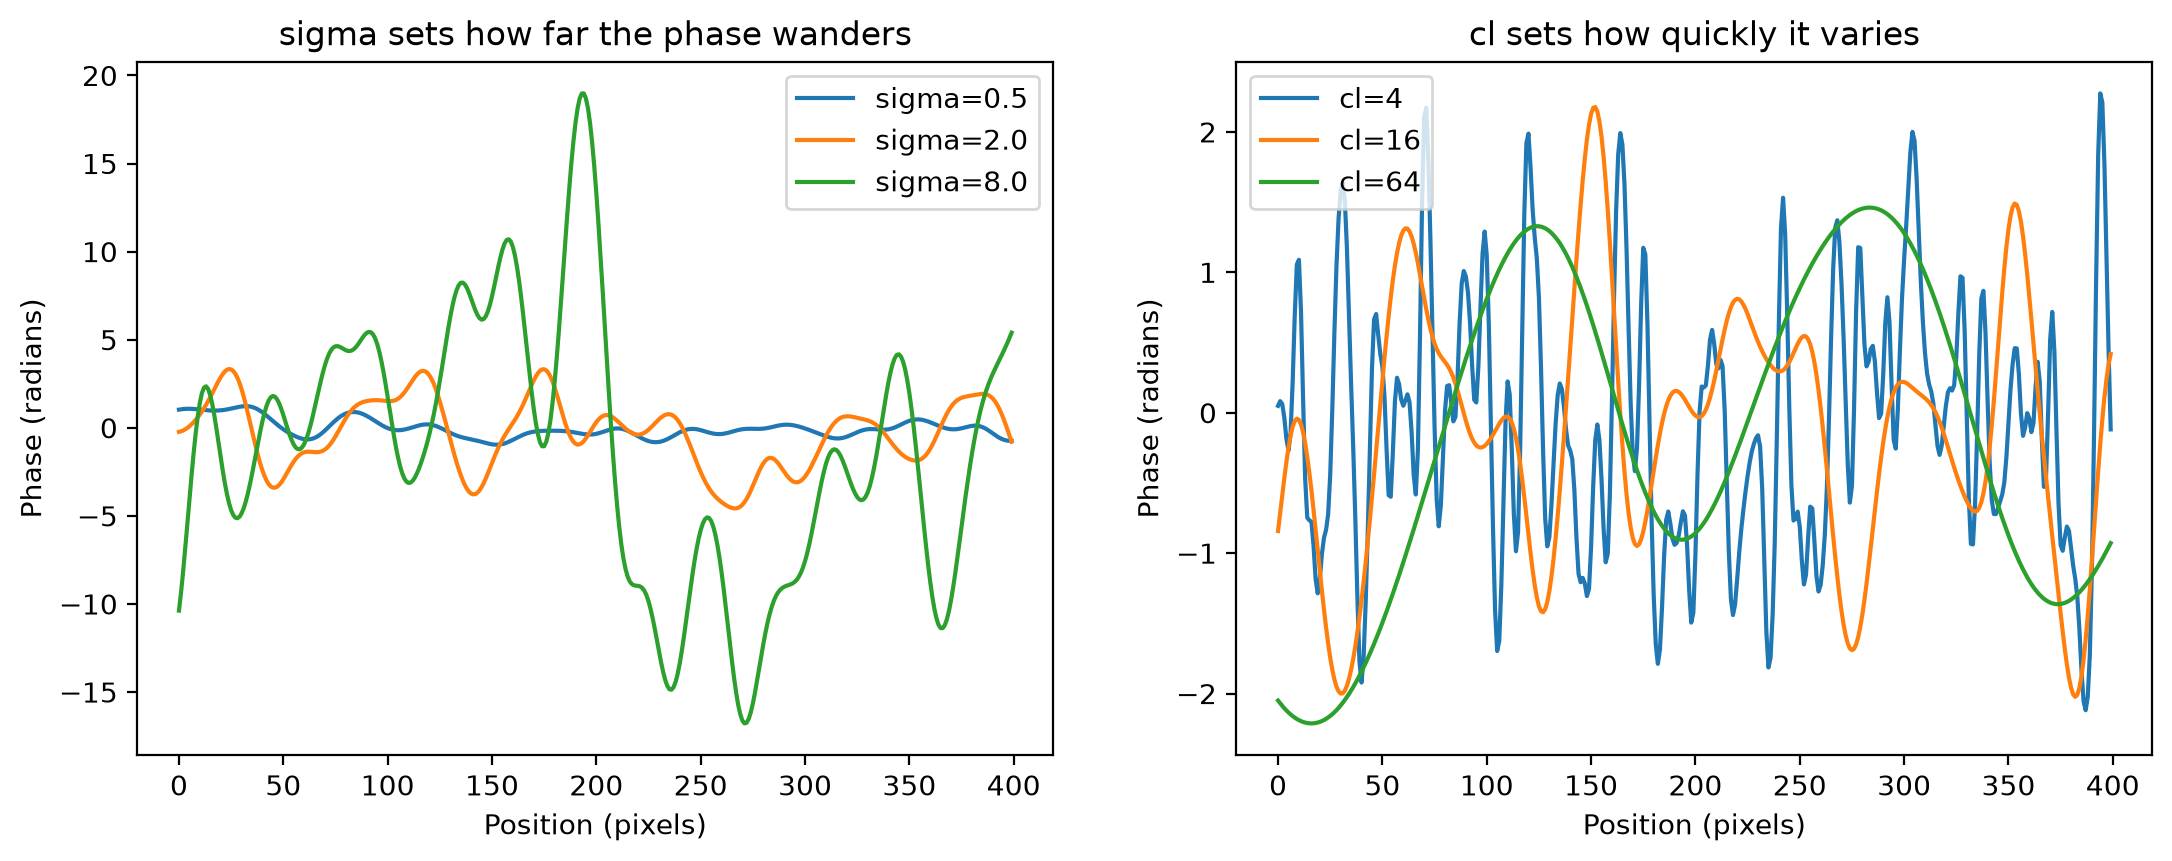

In [9]:
M = 4096

plt.subplots(1, 2, figsize=(13, 4.5))

plt.subplot(1, 2, 1)
for sigma in [0.5, 2.0, 8.0]:
    plt.plot(pyspeckle.create_phase_screen(M, sigma, 16)[:400], label="sigma=%.1f" % sigma)
plt.xlabel("Position (pixels)")
plt.ylabel("Phase (radians)")
plt.title("sigma sets how far the phase wanders")
plt.legend()

plt.subplot(1, 2, 2)
for cl in [4, 16, 64]:
    plt.plot(pyspeckle.create_phase_screen(M, 1.0, cl)[:400], label="cl=%d" % cl)
plt.xlabel("Position (pixels)")
plt.ylabel("Phase (radians)")
plt.title("cl sets how quickly it varies")
plt.legend()

plt.show()

### The correlation shape

`correlation` chooses between $\exp(-x^2/c_l^2)$ and $\exp(-x/c_l)$.  The
exponential form drops sharply at first and then has a long tail; the Gaussian
form stays flat near zero lag and then falls away quickly.

The screen reproduces whichever is asked for, which is worth checking since the
correlation is the whole point of the routine.

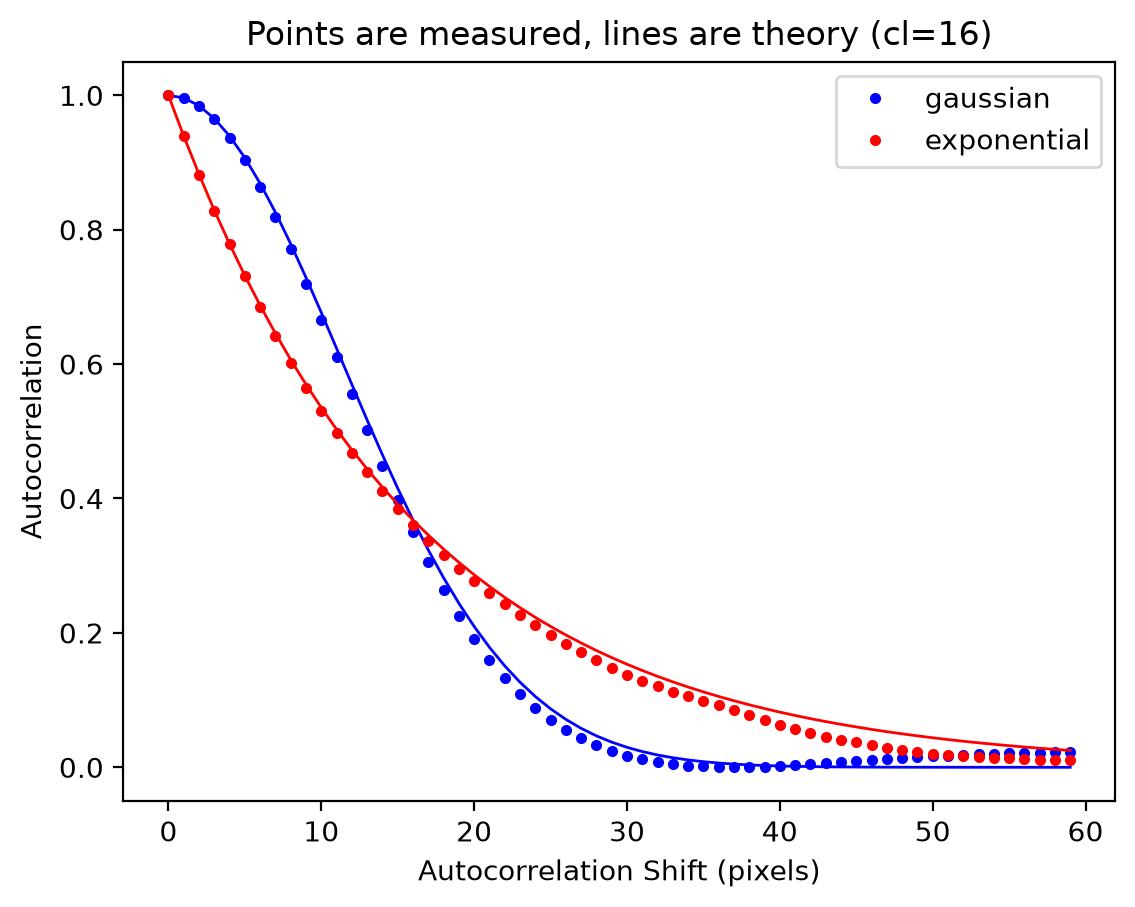

In [10]:
M, cl = 32768, 16
lag = np.arange(60)

for shape, theory, colour in [
    ("gaussian", np.exp(-((lag / cl) ** 2)), "blue"),
    ("exponential", np.exp(-lag / cl), "red"),
]:
    screen = pyspeckle.create_phase_screen(M, 1.0, cl, correlation=shape)
    ac = pyspeckle.autocorrelation(screen)
    plt.plot(lag, ac[: len(lag)], "o", color=colour, markersize=3, label=shape)
    plt.plot(lag, theory, "-", color=colour, lw=1)

plt.xlabel("Autocorrelation Shift (pixels)")
plt.ylabel("Autocorrelation")
plt.title("Points are measured, lines are theory (cl=%d)" % cl)
plt.legend()
plt.show()

## Partially developed speckle

Everything above assumed the scattered phase is uniform over $2\pi$.  If the
surface roughness is comparable to the wavelength that is no longer true: part
of the light is scattered and part continues undeviated, and the speckle is
only *partially* developed.

The phase screens from the previous section are exactly what is needed here.

### How much light is scattered

The fraction of the field that continues undeviated is

$$
\left|\langle e^{i\phi}\rangle\right|^2 = e^{-\sigma^2}
$$

A screen with $\sigma=0.25$ radians leaves 94% of the light unscattered, while
$\sigma=3$ leaves essentially none.

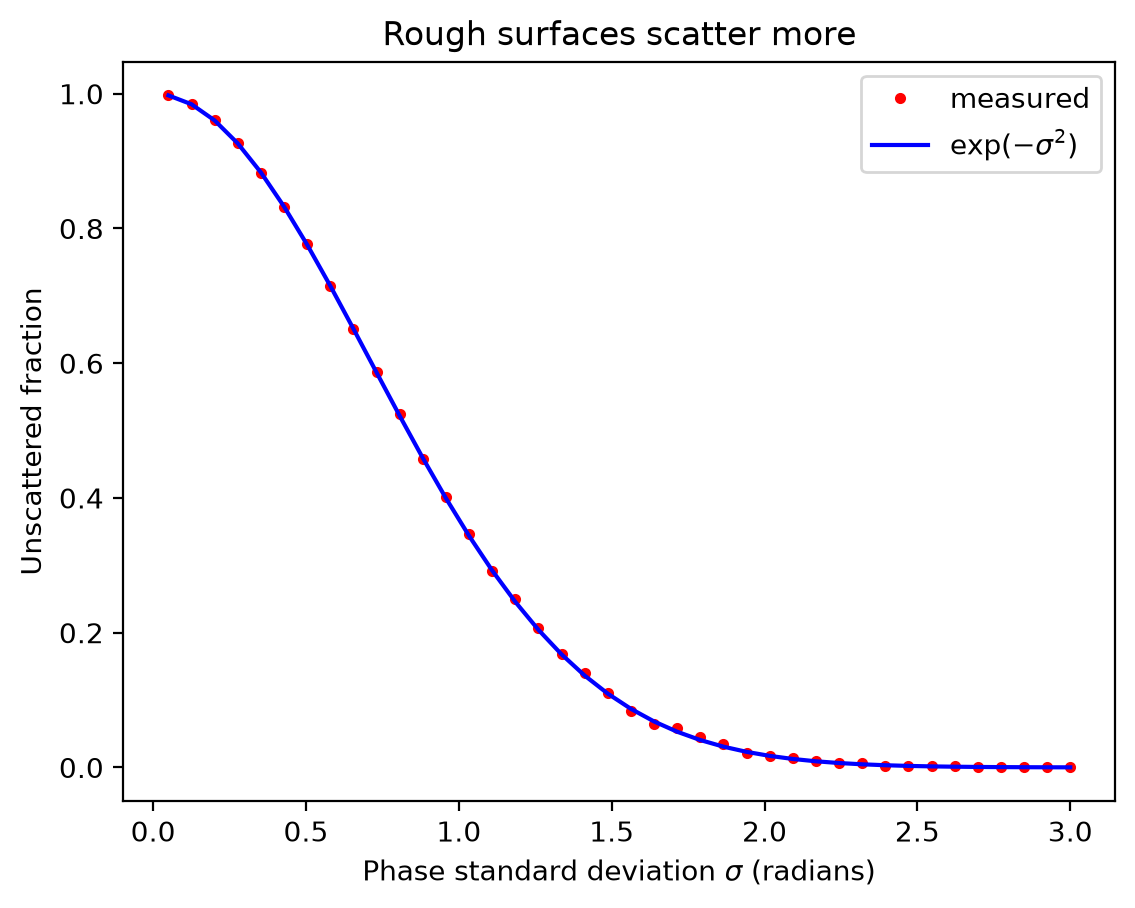

In [11]:
sigmas = np.linspace(0.05, 3, 40)
measured = []
for sigma in sigmas:
    screen = pyspeckle.create_phase_screen(32768, sigma, 8)
    measured.append(abs(np.mean(np.exp(1j * screen))) ** 2)

plt.plot(sigmas, measured, "ro", markersize=3, label="measured")
plt.plot(sigmas, np.exp(-(sigmas**2)), "b", label=r"$\exp(-\sigma^2)$")
plt.xlabel(r"Phase standard deviation $\sigma$ (radians)")
plt.ylabel("Unscattered fraction")
plt.title("Rough surfaces scatter more")
plt.legend()
plt.show()

### From partially to fully developed

Illuminating an aperture with the screen and transforming to the far field
gives the speckle pattern.  For small `sigma` most of the energy stays in the
undeviated spike at the centre and there is little speckle.  As `sigma` grows
the spike disappears and the pattern approaches the fully developed case that
`create_exponential` produces directly.

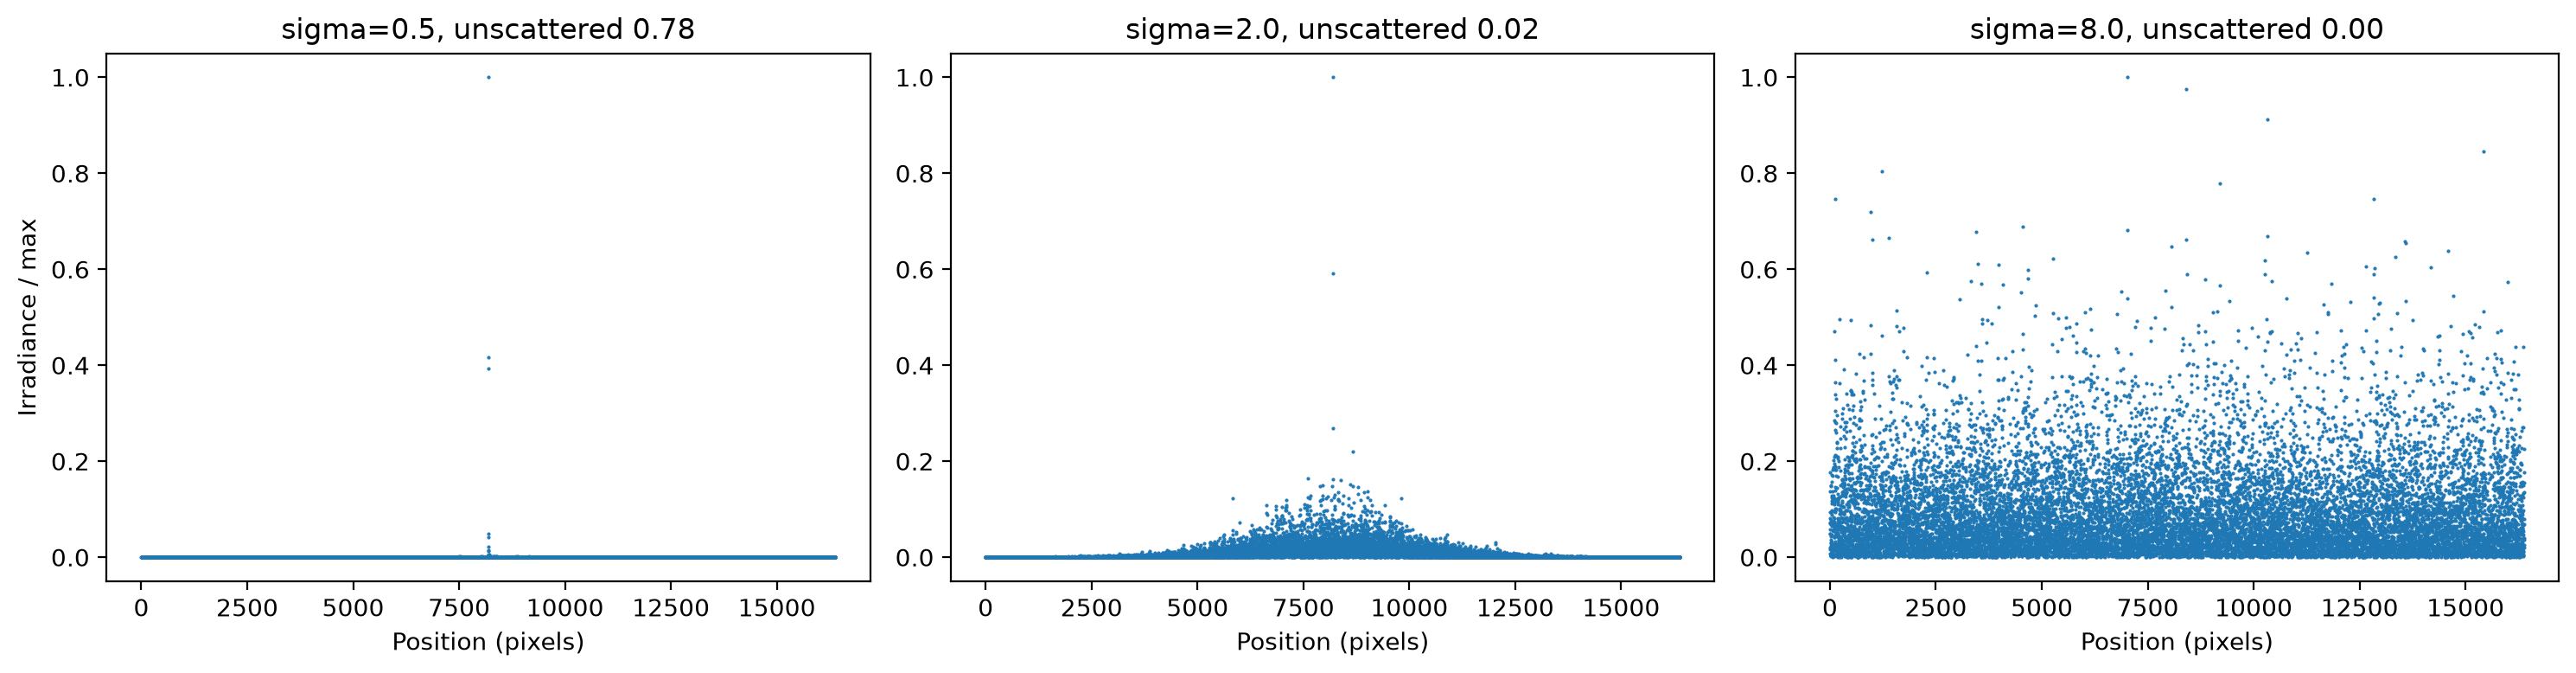

In [12]:
M, L, cl = 8192, 16384, 4

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, sigma in zip(axes, [0.5, 2.0, 8.0]):
    screen = pyspeckle.create_phase_screen(L, sigma, cl)
    u = np.exp(1j * screen)
    u[M:] = 0  # aperture
    I = np.abs(np.fft.fftshift(np.fft.fft(u))) ** 2
    ax.plot(I / I.max(), ".", markersize=1)
    ax.set_title("sigma=%.1f, unscattered %.2f" % (sigma, np.exp(-(sigma**2))))
    ax.set_xlabel("Position (pixels)")
axes[0].set_ylabel("Irradiance / max")
plt.tight_layout()
plt.show()

The transition shows up in the statistics.  Away from the undeviated spike the
contrast and skew both fall toward the fully developed values of 1 and 2 as the
surface roughens.

In [13]:
M, L, cl = 8192, 16384, 4
print("  sigma   unscattered      K     skew")
for sigma in [0.5, 1.0, 2.0, 4.0, 8.0]:
    screen = pyspeckle.create_phase_screen(L, sigma, cl)
    u = np.exp(1j * screen)
    u[M:] = 0
    I = np.abs(np.fft.fftshift(np.fft.fft(u))) ** 2
    middle = len(I) // 2
    keep = np.ones(len(I), dtype=bool)
    keep[middle - 64 : middle + 64] = False  # drop the undeviated spike
    Ik = I[keep]
    skew = np.mean(((Ik - Ik.mean()) / Ik.std()) ** 3)
    print("  %5.1f      %6.3f    %6.2f   %6.2f" % (sigma, np.exp(-(sigma**2)), Ik.std() / Ik.mean(), skew))

reference = pyspeckle.create_exponential(65536, 4)
skew = np.mean(((reference - reference.mean()) / reference.std()) ** 3)
print("\n  fully developed reference: K=%.2f, skew=%.2f" % (np.std(reference) / np.mean(reference), skew))

  sigma   unscattered      K     skew
    0.5       0.779      2.97     5.07
    1.0       0.368      2.69     4.85
    2.0       0.018      2.05     3.86
    4.0       0.000      1.25     2.72
    8.0       0.000      0.99     2.00

  fully developed reference: K=0.99, skew=1.93


## Summary

* `create_exponential` -- fully developed polarized speckle, exponential
  irradiance, contrast 1.
* `create_unpolarized` -- the incoherent sum of two polarizations, gamma-2
  irradiance, contrast $1/\sqrt{2}$.
* `create_phase_screen` -- the correlated Gaussian *phase* imposed by a
  rough surface, the starting point for partially developed speckle.
* `local_contrast_1D` and `local_contrast_1D_plot` -- contrast over a sliding
  window.
* `statistics_plot_1D` -- trace, irradiance density, and power spectrum in one
  figure.

The correlated Gaussian sequences `create_correlated` and
`create_correlated` are covered in the *Correlated Random Sequences*
notebook.  They are not speckle.